# 03 · 쿠션과 승수 — VaR로 m 정하기 · 위험 자본 floor · CPPI

[![Colab에서 열기](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/keerhee/pension-fund-strategy-and-performance/blob/main/W06_LDI%EC%99%80GBI/W06_M8_%EC%8B%A4%EC%8A%B5_Colab/03_VaR_%EC%9C%84%ED%97%98%EC%9E%90%EB%B3%B8_CPPI.ipynb)

**W06 M8 GBI 강의본 76~84장과 62장** 을 재현합니다. 단위는 자산 A = 100(또는 억).

| 단계 | 강의 | 이 노트북에서 |
|---|---|---|
| 쿠션 공식 · 자동 축소 | 76 · 77장 | F 5억 · m 4: A 10 → 100%, 6 → 67%, 5 → 0% |
| m의 세 기준 | 80장 | m ≤ 1/L, Merton m* = (μ − r)/(γσ²) ≈ 2.5 |
| 레버 ① m을 VaR로 | 81장 | m ≤ 1/x: 10 · 20 · 33 · 50% → 10 · 5 · 3 · 2, A 100 · F 80 · m 3 손실 예 |
| 레버 ② floor를 위험 자본으로 | 82장 | L 16.1, σ 15 · 20 · 25% → F 71.2 · 80 · 84.7, E 86.4 · 60 · 46.0 |
| 세 방법이 같은 답 74 | 83 · 84장 | CPPI E ≤ 74 · Das–Markowitz w ≤ 74% · 방법 1 K = 100 |
| CPPI + Das–Markowitz | 62장 | F 80 · E 60 · 충격 −20% → E 24, −40% → floor 뚫림 |
| CPPI 경로 | 44장과 같은 규칙 | 쿠션 · 노출 · floor를 해마다 그린다 |

모두 손계산 수준이라 몇 초 안에 끝납니다.

### 0. 준비 — 이 셀부터 실행
한글 폰트(Colab은 나눔고딕 설치, 맥은 Pretendard), 강의 색(잉크 · 라임 · 티일 · 빨강), 강의본 숫자 확인 함수 `check()`를 준비합니다.
`check(이름, 계산값, 강의값, 허용오차)`는 계산이 강의본 숫자와 허용오차 안에서 맞는지 확인하고, 틀리면 멈춥니다(`assert`).
`FAST = True`로 바꾸면 경로 수를 줄여 빨리 돌고, 이때 확인은 표시만 합니다.

In [1]:
# ── 환경 준비: 한글 폰트 · 강의 색 · 확인 함수 (이 셀을 먼저 실행) ──
import sys, os, glob, math, time, subprocess
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

import warnings
warnings.filterwarnings("ignore", message=".*encountered in matmul")   # 맥 numpy(Accelerate)의 거짓 경고 — 결과와 무관
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB and not glob.glob("/usr/share/fonts/truetype/nanum/NanumGothic*.ttf"):
    # Colab: 나눔 폰트 설치 (= !apt-get -qq install -y fonts-nanum) — 처음 한 번 10초 안팎
    subprocess.run("apt-get -qq install -y fonts-nanum > /dev/null", shell=True)

def setup_korean_font():
    """로컬 맥은 Pretendard, Colab은 나눔고딕을 matplotlib에 등록한다(폰트 캐시 갱신과 같은 효과)."""
    files = (glob.glob(os.path.expanduser("~/Library/Fonts/Pretendard-*.otf"))
             + glob.glob("/Library/Fonts/Pretendard-*.otf")
             + glob.glob("/usr/share/fonts/truetype/nanum/NanumGothic*.ttf"))
    for f in files:
        try:
            fm.fontManager.addfont(f)
        except Exception:
            pass
    names = {f.name for f in fm.fontManager.ttflist}
    for fam in ["Pretendard", "NanumGothic", "AppleGothic", "Malgun Gothic", "Noto Sans CJK KR"]:
        if fam in names:
            plt.rcParams["font.family"] = fam
            return fam
    return "(한글 폰트 없음 — 그래프 글자가 네모로 보이면 이 셀을 다시 실행)"

FONT = setup_korean_font()
plt.rcParams["axes.unicode_minus"] = False

# 강의 색 — 잉크 · 라임 · 티일 · 빨강 (+ 보조 회색 · 아이보리 바탕)
INK, LIME, TEAL, RED = "#071A1D", "#B7F34A", "#0B6B68", "#C00000"
GRAY, IVORY, OLIVE = "#8A9496", "#F7F5F0", "#5E8C1A"
plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110, "savefig.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": IVORY,
    "axes.edgecolor": INK, "axes.labelcolor": INK, "xtick.color": INK, "ytick.color": INK,
    "axes.titleweight": "bold", "axes.titlesize": 13, "axes.titlelocation": "left",
    "axes.grid": True, "grid.color": "#DDD8CC", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "axes.axisbelow": True,
    "axes.prop_cycle": matplotlib.cycler(color=[TEAL, INK, RED, OLIVE, GRAY]),
})

# 빠른 모드 — True면 경로 · 표본 수를 줄여 빨리 끝난다(숫자가 강의와 소수 둘째 자리쯤 달라질 수 있어 확인은 표시만 한다)
FAST = False

CHECKS = []
def check(label, value, lecture, tol, fmt=".4f", unit=""):
    """계산값을 강의본 숫자와 비교한다. 기본(재현) 모드에서는 허용오차를 넘으면 멈춘다(assert)."""
    ok = abs(value - lecture) <= tol + 1e-9      # 허용오차는 보통 강의 표기 자릿수의 반(반올림하면 같은 값)
    CHECKS.append((label, ok))
    print(f"{'✓' if ok else '✗'} {label}: 계산 {value:{fmt}}{unit} · 강의 {lecture:{fmt}}{unit} (허용 ±{tol:g})")
    if not FAST:
        assert ok, f"{label}: 계산 {value} · 강의 {lecture}"

print(f"Colab: {IN_COLAB} · 그래프 폰트: {FONT} · numpy {np.__version__} · matplotlib {matplotlib.__version__}")

Colab: False · 그래프 폰트: Pretendard · numpy 2.0.2 · matplotlib 3.9.4


## 1. 쿠션 공식 — 위험자산 = m × 쿠션 (강의 76 · 77장)
쿠션 C = A − F, 위험 노출 E = m × C, 비중 w = E / A를 0~100%로 자른다(레버리지 금지).
위험자산이 x만큼 떨어지면 손실 m·C·x — **x < 1/m이면 floor가 지켜집니다.**

In [2]:
def cppi_weight(A, F, m):
    """CPPI 위험자산 비중 — m × (A − F) / A를 0~1로 자른다"""
    return np.clip(m * (A - F) / A, 0.0, 1.0)

for A in (10, 6, 5):
    raw = 4 * (A - 5) / A
    print(f"A = {A}억 (F 5억, m 4): 4 × ({A} − 5) / {A} = {raw:.0%} → {cppi_weight(A, 5, 4):.0%}")
check("A 10 자르기 전 (%)", 100 * 4 * (10 - 5) / 10, 200, 0.5, ".0f")
check("A 10 비중 (%)", 100 * cppi_weight(10, 5, 4), 100, 0.5, ".0f")
check("A 6 비중 (%)", 100 * cppi_weight(6, 5, 4), 67, 0.5, ".0f")
check("A 5 비중 (%)", 100 * cppi_weight(5, 5, 4), 0, 0.5, ".0f")

A = 10억 (F 5억, m 4): 4 × (10 − 5) / 10 = 200% → 100%
A = 6억 (F 5억, m 4): 4 × (6 − 5) / 6 = 67% → 67%
A = 5억 (F 5억, m 4): 4 × (5 − 5) / 5 = 0% → 0%
✓ A 10 자르기 전 (%): 계산 200 · 강의 200 (허용 ±0.5)
✓ A 10 비중 (%): 계산 100 · 강의 100 (허용 ±0.5)
✓ A 6 비중 (%): 계산 67 · 강의 67 (허용 ±0.5)
✓ A 5 비중 (%): 계산 0 · 강의 0 (허용 ±0.5)


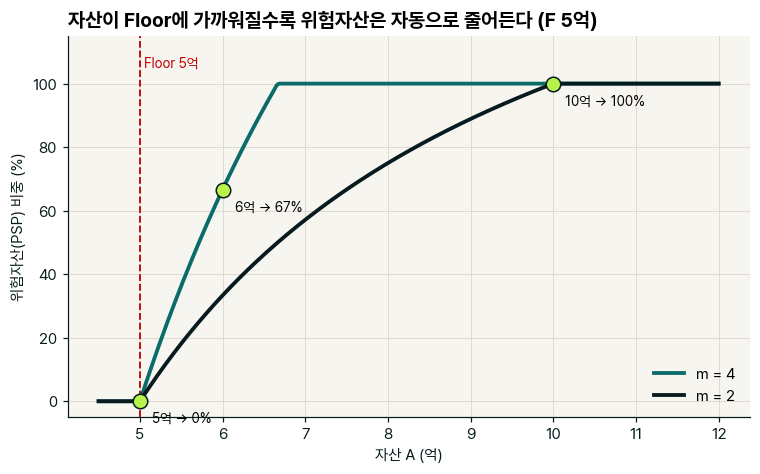

In [3]:
As = np.linspace(4.5, 12, 300)
fig, ax = plt.subplots()
for m, c in [(4, TEAL), (2, INK)]:
    ax.plot(As, cppi_weight(As, 5, m) * 100, color=c, lw=2.5, label=f"m = {m}")
ax.axvline(5, color=RED, ls="--", lw=1.2); ax.text(5.05, 105, "Floor 5억", color=RED, fontsize=9)
for A, w in [(10, 1.0), (6, 2 / 3), (5, 0.0)]:
    ax.scatter(A, w * 100, s=90, color=LIME, edgecolor=INK, zorder=5)
    ax.annotate(f"{A}억 → {w:.0%}", (A, w * 100), xytext=(8, -14), textcoords="offset points", fontsize=9)
ax.set_xlabel("자산 A (억)"); ax.set_ylabel("위험자산(PSP) 비중 (%)"); ax.set_ylim(-5, 115)
ax.set_title("자산이 Floor에 가까워질수록 위험자산은 자동으로 줄어든다 (F 5억)")
ax.legend(loc="lower right"); plt.show()

## 2. 승수 m의 세 기준 (강의 80장)
① 급락 상한 m ≤ 1/L(L = 견딜 손실) ② 효용 기준(Merton) m\* = (μ − r)/(γσ²) ③ 목표 확률(몬테카를로 — 04~06 노트북).
m은 ①과 ② 중 작은 값, 마지막은 몬테카를로로 목표 확률을 맞춥니다.

In [4]:
for lab, L, lect in [("월 99% VaR ≈ 12% (연 σ 18%)", 0.12, 8), ("하루 −20% (1987 블랙먼데이)", 0.20, 5), ("−25% 급락 (강의 예시)", 0.25, 4)]:
    print(f"{lab:28s} m ≤ 1/{L:.0%} = {1 / L:.2f} → {int(1 / L)}")
    check(f"m 상한 · {lab}", int(1 / L), lect, 0.5, ".0f")
m_star = 0.04 / (0.5 * 0.18**2)
print(f"Merton m* = (μ − r)/(γσ²) = 4% / (0.5 × 18%²) = {m_star:.2f}")
check("Merton m*", m_star, 2.5, 0.05, ".2f")

월 99% VaR ≈ 12% (연 σ 18%)    m ≤ 1/12% = 8.33 → 8
✓ m 상한 · 월 99% VaR ≈ 12% (연 σ 18%): 계산 8 · 강의 8 (허용 ±0.5)
하루 −20% (1987 블랙먼데이)         m ≤ 1/20% = 5.00 → 5
✓ m 상한 · 하루 −20% (1987 블랙먼데이): 계산 5 · 강의 5 (허용 ±0.5)
−25% 급락 (강의 예시)              m ≤ 1/25% = 4.00 → 4
✓ m 상한 · −25% 급락 (강의 예시): 계산 4 · 강의 4 (허용 ±0.5)
Merton m* = (μ − r)/(γσ²) = 4% / (0.5 × 18%²) = 2.47
✓ Merton m*: 계산 2.47 · 강의 2.50 (허용 ±0.05)


## 3. 레버 ① — 승수 m을 VaR로 정한다 (강의 81장)
리밸런싱 사이 최악 하락률 x에서 손실 E × x ≤ C이면 floor가 지켜진다 → **m ≤ 1/x**.

In [5]:
for x, lect in [(0.10, 10), (0.20, 5), (0.33, 3), (0.50, 2)]:
    print(f"x = {x:.0%} → m 상한 = 1 ÷ {x:.0%} = {1 / x:.2f}")
    check(f"m 상한 (x {x:.0%})", 1 / x, lect, 0.05, ".2f")
A, F, m = 100.0, 80.0, 3.0
C0 = A - F; E0 = m * C0
print(f"\nA = {A:.0f}, F = {F:.0f}, m = {m:.0f} → 쿠션 C = {C0:.0f} → 위험 노출 E = {E0:.0f}")
for x in (0.20, 0.40):
    loss = E0 * x
    print(f"x = {x:.0%}: 손실 = {E0:.0f} × {x:.0%} = {loss:.0f} {'≤' if loss <= C0 else '>'} C = {C0:.0f} → "
          f"{'floor 지킴' if loss <= C0 else 'floor 뚫림'} (m = 3 {'≤' if m <= 1 / x else '>'} 1/x = {1 / x:.1f})")
check("x 20% 손실", E0 * 0.20, 12, 1e-9, ".0f"); check("x 40% 손실", E0 * 0.40, 24, 1e-9, ".0f")
check("x 40%의 1/x", 1 / 0.40, 2.5, 1e-9, ".1f")

x = 10% → m 상한 = 1 ÷ 10% = 10.00
✓ m 상한 (x 10%): 계산 10.00 · 강의 10.00 (허용 ±0.05)
x = 20% → m 상한 = 1 ÷ 20% = 5.00
✓ m 상한 (x 20%): 계산 5.00 · 강의 5.00 (허용 ±0.05)
x = 33% → m 상한 = 1 ÷ 33% = 3.03
✓ m 상한 (x 33%): 계산 3.03 · 강의 3.00 (허용 ±0.05)
x = 50% → m 상한 = 1 ÷ 50% = 2.00
✓ m 상한 (x 50%): 계산 2.00 · 강의 2.00 (허용 ±0.05)

A = 100, F = 80, m = 3 → 쿠션 C = 20 → 위험 노출 E = 60
x = 20%: 손실 = 60 × 20% = 12 ≤ C = 20 → floor 지킴 (m = 3 ≤ 1/x = 5.0)
x = 40%: 손실 = 60 × 40% = 24 > C = 20 → floor 뚫림 (m = 3 > 1/x = 2.5)
✓ x 20% 손실: 계산 12 · 강의 12 (허용 ±1e-09)
✓ x 40% 손실: 계산 24 · 강의 24 (허용 ±1e-09)
✓ x 40%의 1/x: 계산 2.5 · 강의 2.5 (허용 ±1e-09)


## 4. 레버 ② — floor를 위험 자본으로 (강의 82장 · 보충교재 3-6 (c))
손실 예산 L(95% VaR 손실)을 고정하고 floor를 다시 정한다: x = 1.645σ − μ, **C = L ÷ (m·x)**, F = A − C, E = m·C.
기준(σ 20%)에서 C = 20이 되게 L = m × x × C = 3 × 26.9% × 20 = 16.1. 위험 ↑ → floor ↑ · 쿠션 ↓ · 노출 ↓, VaR 손실은 16.1 그대로.

In [6]:
mu = 0.06
x_of = lambda s: 1.645 * s - mu
L_budget = 3 * x_of(0.20) * 20
print(f"L = 3 × {x_of(0.20):.1%} × 20 = {L_budget:.2f}")
LECT = {0.15: (18.7, 28.8, 71.2, 86.4), 0.20: (26.9, 20.0, 80.0, 60.0), 0.25: (35.1, 15.3, 84.7, 46.0)}
RC = {}
print(f"{'σ':>5s} {'x':>7s} {'C':>7s} {'F':>7s} {'E':>7s} {'E·x':>7s}")
for s, (lx, lc, lf, le) in LECT.items():
    x = x_of(s); Cc = L_budget / (3 * x); Ff = 100 - Cc; Ee = 3 * Cc
    RC[s] = (x, Cc, Ff, Ee)
    print(f"{s:5.0%} {x:7.1%} {Cc:7.1f} {Ff:7.1f} {Ee:7.1f} {Ee * x:7.2f}")
    check(f"σ {s:.0%} x (%)", 100 * x, lx, 0.05, ".1f"); check(f"σ {s:.0%} 쿠션 C", Cc, lc, 0.05, ".1f")
    check(f"σ {s:.0%} floor F", Ff, lf, 0.05, ".1f"); check(f"σ {s:.0%} 노출 E", Ee, le, 0.06, ".1f")
check("손실 예산 L", L_budget, 16.1, 0.05, ".2f")

L = 3 × 26.9% × 20 = 16.14
    σ       x       C       F       E     E·x
  15%   18.7%    28.8    71.2    86.4   16.14
✓ σ 15% x (%): 계산 18.7 · 강의 18.7 (허용 ±0.05)
✓ σ 15% 쿠션 C: 계산 28.8 · 강의 28.8 (허용 ±0.05)
✓ σ 15% floor F: 계산 71.2 · 강의 71.2 (허용 ±0.05)
✓ σ 15% 노출 E: 계산 86.4 · 강의 86.4 (허용 ±0.06)
  20%   26.9%    20.0    80.0    60.0   16.14
✓ σ 20% x (%): 계산 26.9 · 강의 26.9 (허용 ±0.05)
✓ σ 20% 쿠션 C: 계산 20.0 · 강의 20.0 (허용 ±0.05)
✓ σ 20% floor F: 계산 80.0 · 강의 80.0 (허용 ±0.05)
✓ σ 20% 노출 E: 계산 60.0 · 강의 60.0 (허용 ±0.06)
  25%   35.1%    15.3    84.7    46.0   16.14
✓ σ 25% x (%): 계산 35.1 · 강의 35.1 (허용 ±0.05)
✓ σ 25% 쿠션 C: 계산 15.3 · 강의 15.3 (허용 ±0.05)
✓ σ 25% floor F: 계산 84.7 · 강의 84.7 (허용 ±0.05)
✓ σ 25% 노출 E: 계산 46.0 · 강의 46.0 (허용 ±0.06)
✓ 손실 예산 L: 계산 16.14 · 강의 16.10 (허용 ±0.05)


**그래프 — σ에 따른 floor F와 위험 노출 E.** 막대 셋은 강의 표(σ 15 · 20 · 25%), 선은 σ 14~35% 전체(σ가 더 낮으면 E가 자산을 넘어 레버리지가 된다).

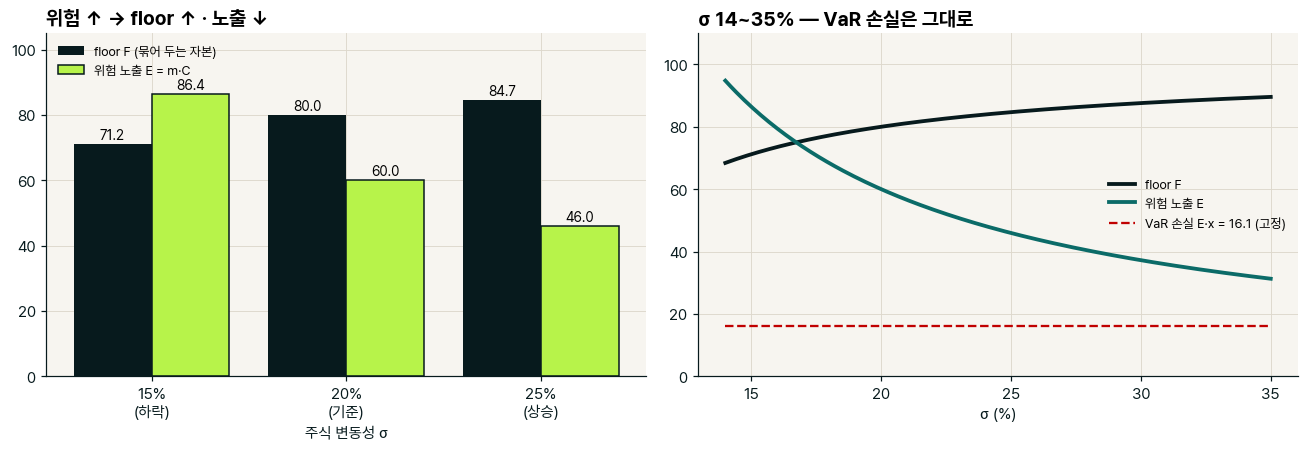

In [7]:
sgs = np.linspace(0.14, 0.35, 200)       # σ 14% 아래면 E가 자산 100을 넘어(레버리지) 뺀다
Fs = 100 - L_budget / (3 * x_of(sgs)); Es = 3 * L_budget / (3 * x_of(sgs))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
lab = ["15%\n(하락)", "20%\n(기준)", "25%\n(상승)"]
xs = np.arange(3)
Fv = [RC[s][2] for s in RC]; Ev = [RC[s][3] for s in RC]
b1 = ax1.bar(xs - 0.2, Fv, 0.4, color=INK, label="floor F (묶어 두는 자본)")
b2 = ax1.bar(xs + 0.2, Ev, 0.4, color=LIME, edgecolor=INK, label="위험 노출 E = m·C")
for bars in (b1, b2):
    for b in bars:
        ax1.text(b.get_x() + b.get_width() / 2, b.get_height() + 1.5, f"{b.get_height():.1f}", ha="center", fontsize=9)
ax1.set_xticks(xs, lab); ax1.set_xlabel("주식 변동성 σ"); ax1.set_ylim(0, 105)
ax1.set_title("위험 ↑ → floor ↑ · 노출 ↓"); ax1.legend(loc="upper left", fontsize=8.5)
ax2.plot(sgs * 100, Fs, color=INK, lw=2.5, label="floor F")
ax2.plot(sgs * 100, Es, color=TEAL, lw=2.5, label="위험 노출 E")
ax2.plot(sgs * 100, Es * x_of(sgs), color=RED, lw=1.5, ls="--", label=f"VaR 손실 E·x = {L_budget:.1f} (고정)")
ax2.set_xlabel("σ (%)"); ax2.set_ylim(0, 110); ax2.set_title("σ 14~35% — VaR 손실은 그대로"); ax2.legend(fontsize=8.5)
fig.tight_layout(); plt.show()

## 5. 세 방법이 같은 답 74에 닿는다 (강의 83 · 84장)
공통 가정: μ 6%, σ 20%, z 1.645, 무위험 0 · 1년 · 정규, 이번엔 F = 80을 고정. 나쁜 경우 하락률 x = zσ − μ = 26.9%.
- CPPI + VaR: E ≤ C/x = (100 − 80)/0.269 = 74, m ≤ 1/x = 3.7
- 방법 2 Das–Markowitz: H = −20%(= floor 80/100 − 1) → w(μ − zσ) ≥ −20% → w ≤ 20%/26.9% = 74%
- 방법 1 필요 자본: w = 74%면 μp 4.5% · σp 14.9% → K = 80/(1 + 4.5% − 24.5%) = 80/0.80 = 100 = A

In [8]:
x = 1.645 * 0.20 - 0.06
E_max = (100 - 80) / x; m_max = 1 / x
w_dm = 0.20 / x
mu_p, s_p = w_dm * 0.06, w_dm * 0.20
K_m1 = 80 / (1 + mu_p - 1.645 * s_p)
print(f"x = {x:.1%} · CPPI E ≤ {E_max:.1f} (m ≤ {m_max:.2f}) · Das–Markowitz w ≤ {w_dm:.1%}")
print(f"방법 1: μp = {mu_p:.2%} · σp = {s_p:.2%} · 나쁜 경우 {mu_p - 1.645 * s_p:.1%} → K = 80 / {1 + mu_p - 1.645 * s_p:.3f} = {K_m1:.1f}")
check("x (%)", 100 * x, 26.9, 0.05, ".1f"); check("CPPI E 상한", E_max, 74, 0.5, ".1f"); check("m 상한", m_max, 3.7, 0.05, ".2f")
check("Das–Markowitz w 상한 (%)", 100 * w_dm, 74, 0.5, ".1f")
check("방법 1 μp (%)", 100 * mu_p, 4.5, 0.05, ".2f"); check("방법 1 σp (%)", 100 * s_p, 14.9, 0.05, ".2f")
check("방법 1 나쁜 경우 (%)", 100 * (mu_p - 1.645 * s_p), -20, 0.05, ".1f"); check("방법 1 K", K_m1, 100, 0.05, ".1f")

x = 26.9% · CPPI E ≤ 74.3 (m ≤ 3.72) · Das–Markowitz w ≤ 74.3%
방법 1: μp = 4.46% · σp = 14.87% · 나쁜 경우 -20.0% → K = 80 / 0.800 = 100.0
✓ x (%): 계산 26.9 · 강의 26.9 (허용 ±0.05)
✓ CPPI E 상한: 계산 74.3 · 강의 74.0 (허용 ±0.5)
✓ m 상한: 계산 3.72 · 강의 3.70 (허용 ±0.05)
✓ Das–Markowitz w 상한 (%): 계산 74.3 · 강의 74.0 (허용 ±0.5)
✓ 방법 1 μp (%): 계산 4.46 · 강의 4.50 (허용 ±0.05)
✓ 방법 1 σp (%): 계산 14.87 · 강의 14.90 (허용 ±0.05)
✓ 방법 1 나쁜 경우 (%): 계산 -20.0 · 강의 -20.0 (허용 ±0.05)
✓ 방법 1 K: 계산 100.0 · 강의 100.0 (허용 ±0.05)


## 6. 바닥은 CPPI가, 위험 블록의 구성은 Das–Markowitz가 (강의 62장)
위험 블록 = 계정별 롱온리 Das–Markowitz 해의 합산(은퇴 60 · 교육 20 · 상속 20%) → **39.9 · 24.7 · 35.4%**, 기대 13.30%, σ 19.38%.
(02 노트북에서 푼 것을 이 노트북 안에서 다시 계산 — 파일 하나만 열어도 돌게)

In [9]:
from scipy.stats import norm
from scipy.optimize import brentq, minimize
MU = np.array([0.05, 0.10, 0.25]); S = np.array([[0.0025, 0, 0], [0, 0.04, 0.02], [0, 0.02, 0.25]])
Si = np.linalg.inv(S); one = np.ones(3)
A_, C_ = one @ Si @ MU, one @ Si @ one; d_ = MU @ Si @ MU - A_**2 / C_
g, v = Si @ one / C_, Si @ (MU - A_ / C_ * one)
def dm_unconstrained(H, alpha):
    z = -norm.ppf(alpha)
    x_ = brentq(lambda t: A_ / C_ + d_ * t - z * math.sqrt(1 / C_ + d_ * t * t) - H, 1e-9, 10)
    return g + v * x_
def dm_long_only(H, alpha):
    z = -norm.ppf(alpha)
    cons = [{"type": "eq", "fun": lambda w: w.sum() - 1}, {"type": "ineq", "fun": lambda w: w @ MU - z * np.sqrt(w @ S @ w) - H}]
    return minimize(lambda w: -w @ MU, [1/3] * 3, method="SLSQP", bounds=[(0, 1)] * 3, constraints=cons).x
block = 0.6 * dm_unconstrained(-0.10, 0.05) + 0.2 * dm_unconstrained(-0.05, 0.15) + 0.2 * dm_long_only(-0.15, 0.20)
mb, sb = block @ MU, math.sqrt(block @ S @ block)
print(f"위험 블록 {np.round(100 * block, 2)}% · 기대 {mb:.2%} · σ {sb:.2%}")
check("위험 블록 기대 (%)", 100 * mb, 13.30, 0.005, ".2f"); check("위험 블록 σ (%)", 100 * sb, 19.38, 0.005, ".2f")
xb = 1.645 * sb - mb
print(f"합산 x = 1.645 × {sb:.2%} − {mb:.2%} = {xb:.1%} → 1/x = {1 / xb:.1f} ≥ m = 3")
check("합산 x (%)", 100 * xb, 18.6, 0.05, ".1f"); check("합산 1/x", 1 / xb, 5.4, 0.05, ".1f")

위험 블록 [39.94 24.71 35.35]% · 기대 13.30% · σ 19.38%
✓ 위험 블록 기대 (%): 계산 13.30 · 강의 13.30 (허용 ±0.005)
✓ 위험 블록 σ (%): 계산 19.38 · 강의 19.38 (허용 ±0.005)
합산 x = 1.645 × 19.38% − 13.30% = 18.6% → 1/x = 5.4 ≥ m = 3
✓ 합산 x (%): 계산 18.6 · 강의 18.6 (허용 ±0.05)
✓ 합산 1/x: 계산 5.4 · 강의 5.4 (허용 ±0.05)


In [10]:
A, F, m = 100.0, 80.0, 3.0
E = m * (A - F); ghp = A - E
print(f"① CPPI: C = {A - F:.0f}, E = {E:.0f} (= 위험 블록, 구성 {np.round(100 * block, 1)}%), GHP = {ghp:.0f}")
SHOCK = {}
for shock in (-0.20, -0.40):
    E1 = E * (1 + shock); A1 = ghp + E1; C1 = A1 - F
    if C1 >= 0:
        E2 = m * C1
        print(f"위험 블록 {shock:+.0%}: E {E:.0f} → {E1:.0f}, A = {ghp:.0f} + {E1:.0f} = {A1:.0f}, C = {C1:.0f} → E = 3 × {C1:.0f} = {E2:.0f} ({E1 - E2:.0f} 매도)")
    else:
        E2 = 0.0
        print(f"위험 블록 {shock:+.0%}: E {E:.0f} → {E1:.0f}, A = {A1:.0f} < F = {F:.0f} → floor 뚫림 (한 번에 1/m = 33%를 넘는 갭 위험)")
    SHOCK[shock] = (E1, A1, C1, E2)
check("−20%: 충격 뒤 E", SHOCK[-0.20][0], 48, 1e-9, ".0f"); check("−20%: A", SHOCK[-0.20][1], 88, 1e-9, ".0f")
check("−20%: 새 E", SHOCK[-0.20][3], 24, 1e-9, ".0f"); check("−40%: A", SHOCK[-0.40][1], 76, 1e-9, ".0f")
assert SHOCK[-0.40][1] < F, "−40%면 floor가 뚫려야 한다"

① CPPI: C = 20, E = 60 (= 위험 블록, 구성 [39.9 24.7 35.3]%), GHP = 40
위험 블록 -20%: E 60 → 48, A = 40 + 48 = 88, C = 8 → E = 3 × 8 = 24 (24 매도)
위험 블록 -40%: E 60 → 36, A = 76 < F = 80 → floor 뚫림 (한 번에 1/m = 33%를 넘는 갭 위험)
✓ −20%: 충격 뒤 E: 계산 48 · 강의 48 (허용 ±1e-09)
✓ −20%: A: 계산 88 · 강의 88 (허용 ±1e-09)
✓ −20%: 새 E: 계산 24 · 강의 24 (허용 ±1e-09)
✓ −40%: A: 계산 76 · 강의 76 (허용 ±1e-09)


## 7. CPPI 경로 — 쿠션 · 노출 · floor를 해마다 (강의 44장과 같은 규칙)
강의 44장의 CPPI 표와 같은 규칙: 자산 10억, floor = 목표 9억의 현재가치 F(t) = 9 × e^(−0.02(10 − t)), m = 3, 노출은 0과 자산 사이로 자름,
나머지는 GHP(연 2.02%). 주식 연 수익률은 **seed 2026의 경로 1**(04 노트북과 같은 난수) — 앞 3년 −9.4 · +11.4 · −27.3%.
비교를 위해 같은 경로에 **2년차 −40% 급락**을 넣은 경로도 굴립니다(1/m = 33%를 넘는 갭).

In [11]:
SEED, T = 2026, 10
r_log, lam, sig = 0.02, 0.06, 0.20
RG = math.exp(r_log) - 1
eps = np.random.default_rng(SEED).standard_normal((1, T))[0]       # 100,000 × 10 행렬을 만들 때의 첫 행과 같다
R1 = np.exp(r_log + lam - 0.5 * sig**2 + sig * eps) - 1
print("경로 1 주식 연 수익률:", " ".join(f"{x:+.1%}" for x in R1))
check("경로 1 1년차 R (%)", 100 * R1[0], -9.4, 0.05, ".1f"); check("경로 1 2년차 R (%)", 100 * R1[1], 11.4, 0.05, ".1f")
check("경로 1 3년차 R (%)", 100 * R1[2], -27.3, 0.05, ".1f")

def cppi_path(R, W0=10.0, G=9.0, m=3.0):
    W = [W0]; Fs, Cs, Es = [], [], []
    for t in range(len(R)):
        Ft = G * math.exp(-r_log * (T - t)); Ct = W[-1] - Ft; Et = min(max(m * Ct, 0.0), W[-1])
        W.append(Et * (1 + R[t]) + (W[-1] - Et) * (1 + RG))
        Fs.append(Ft); Cs.append(Ct); Es.append(Et)
    return np.array(W), np.array(Fs), np.array(Cs), np.array(Es)

Wa, Fa, Ca, Ea = cppi_path(R1)
for t in range(3):
    print(f"{t + 1}년차: F {Fa[t]:.2f} → C {Ca[t]:.2f} → E {Ea[t]:.2f} → 끝 자산 {Wa[t + 1]:.2f}")
for t, (f_, e_, w_) in enumerate([(7.37, 7.89, 9.30), (7.52, 5.35, 9.99), (7.67, 6.97, 8.15)]):
    check(f"CPPI {t + 1}년차 F", Fa[t], f_, 0.005, ".2f"); check(f"CPPI {t + 1}년차 E", Ea[t], e_, 0.005, ".2f")
    check(f"CPPI {t + 1}년차 끝 자산", Wa[t + 1], w_, 0.005, ".2f")
R2 = R1.copy(); R2[1] = -0.40
Wb, Fb, Cb, Eb = cppi_path(R2)
print(f"\n2년차 −40% 경로: 2년차 끝 자산 {Wb[2]:.2f} vs floor {9 * math.exp(-r_log * (T - 2)):.2f} → "
      f"{'floor 뚫림' if Wb[2] < 9 * math.exp(-r_log * (T - 2)) else '지킴'} · 10년 뒤 {Wb[-1]:.2f}억")

경로 1 주식 연 수익률: -9.4% +11.4% -27.3% +40.4% +20.6% +0.2% -0.2% +12.8% +0.6% +1.5%
✓ 경로 1 1년차 R (%): 계산 -9.4 · 강의 -9.4 (허용 ±0.05)
✓ 경로 1 2년차 R (%): 계산 11.4 · 강의 11.4 (허용 ±0.05)
✓ 경로 1 3년차 R (%): 계산 -27.3 · 강의 -27.3 (허용 ±0.05)
1년차: F 7.37 → C 2.63 → E 7.89 → 끝 자산 9.30
2년차: F 7.52 → C 1.78 → E 5.35 → 끝 자산 9.99
3년차: F 7.67 → C 2.32 → E 6.97 → 끝 자산 8.15
✓ CPPI 1년차 F: 계산 7.37 · 강의 7.37 (허용 ±0.005)
✓ CPPI 1년차 E: 계산 7.89 · 강의 7.89 (허용 ±0.005)
✓ CPPI 1년차 끝 자산: 계산 9.30 · 강의 9.30 (허용 ±0.005)
✓ CPPI 2년차 F: 계산 7.52 · 강의 7.52 (허용 ±0.005)
✓ CPPI 2년차 E: 계산 5.35 · 강의 5.35 (허용 ±0.005)
✓ CPPI 2년차 끝 자산: 계산 9.99 · 강의 9.99 (허용 ±0.005)
✓ CPPI 3년차 F: 계산 7.67 · 강의 7.67 (허용 ±0.005)
✓ CPPI 3년차 E: 계산 6.97 · 강의 6.97 (허용 ±0.005)
✓ CPPI 3년차 끝 자산: 계산 8.15 · 강의 8.15 (허용 ±0.005)

2년차 −40% 경로: 2년차 끝 자산 7.24 vs floor 7.67 → floor 뚫림 · 10년 뒤 8.50억


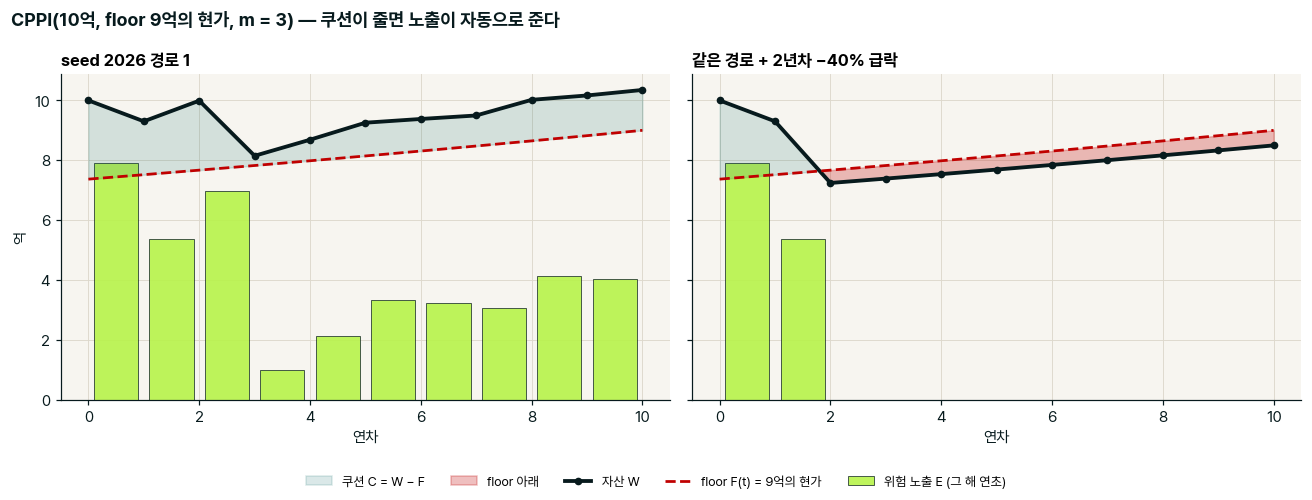

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
yrs = np.arange(T + 1)
F_line = 9 * np.exp(-r_log * (T - yrs))
for ax, (W, Fv, Cv, Ev), ttl in [(axes[0], (Wa, Fa, Ca, Ea), "seed 2026 경로 1"), (axes[1], (Wb, Fb, Cb, Eb), "같은 경로 + 2년차 −40% 급락")]:
    ax.bar(yrs[:-1] + 0.5, Ev, 0.8, color=LIME, edgecolor=INK, lw=0.5, alpha=0.9, label="위험 노출 E (그 해 연초)")
    ax.fill_between(yrs, F_line, W, where=W >= F_line, color=TEAL, alpha=0.15, interpolate=True, label="쿠션 C = W − F")
    ax.fill_between(yrs, W, F_line, where=W < F_line, color=RED, alpha=0.25, interpolate=True, label="floor 아래")
    ax.plot(yrs, W, color=INK, lw=2.5, marker="o", ms=4, label="자산 W")
    ax.plot(yrs, F_line, color=RED, lw=1.8, ls="--", label="floor F(t) = 9억의 현가")
    ax.set_title(ttl, fontsize=11); ax.set_xlabel("연차")
axes[0].set_ylabel("억")
h, l = axes[1].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=5, fontsize=8.5)
fig.suptitle("CPPI(10억, floor 9억의 현가, m = 3) — 쿠션이 줄면 노출이 자동으로 준다", x=0.01, ha="left", fontweight="bold", color=INK)
fig.tight_layout(rect=(0, 0.07, 1, 1)); plt.show()

**읽는 법** — 급락이 1/m = 33%를 넘으면 한 해 사이에 쿠션이 다 사라지고 floor를 뚫습니다(갭 위험). 쿠션이 0 근처면 노출도 0이라
다시 오르지 못하는 Cash Trap에 갇힙니다(85장). 이런 꼬리 사건이 **몇 %의 경로에서 일어나는지는 경로를 세어야** 압니다 → 06 노트북(floor 위반 1.9% → t5 3.3%).

---
### 확인 결과 요약
이 노트북에서 강의본 숫자와 비교한 항목을 모아 봅니다. 모두 ✓이면 강의본 숫자를 그대로 재현한 것입니다.

In [13]:
# ── 확인 결과 요약 ──
n_ok = sum(ok for _, ok in CHECKS)
print(f"강의본 숫자 확인 {n_ok} / {len(CHECKS)} 통과" + (" — 빠른 모드라 일부 차이는 정상" if FAST else ""))
for label, ok in CHECKS:
    if not ok:
        print("  ✗", label)

강의본 숫자 확인 56 / 56 통과


---
## 바꿔 보기 (연습 문제)

1. m을 3 → 5로 바꾸면(`cppi_path(R1, m=5)`) 경로 1의 10년 뒤 자산과 2년차 −40% 경로의 결과는? 1/x 기준으로 m 5가 견디는 최악 하락률은?
2. 레버 ②에서 σ가 30%로 오르면 floor F와 노출 E는? 손실 예산 L을 20으로 늘리면?
3. floor를 9억 → 7억의 현가로 낮추면 급락 경로에서 floor를 지키는가? 대신 무엇을 잃는가?

아래 빈 셀에서 직접 해 보세요. 위 셀의 함수를 그대로 불러 쓰면 됩니다.

In [14]:
# 여기에 직접 해 보기

In [15]:
# 여기에 직접 해 보기

In [16]:
# 여기에 직접 해 보기